# ADALINE-Based Parameter Estimation for Axial Flux PMSM
## Method-led notebook for WLTP flux and resistance estimation

This notebook estimates PMSM dq-axis flux linkage surfaces from transient WLTP
drive-cycle data using Adaptive Linear Element Networks (ADALINE), then compares
the estimated surfaces with YASA GPR reference data at multiple operating speeds.
Each section explains the physical question being answered, the modelling
decision, and how the result is implemented.

### Theoretical background

ADALINE treats the PMSM dq voltage equations as a linear-in-parameters
regression problem. Three ADALINE sub-networks estimate sequentially:
$\psi_f$ (PM flux), $R_s$ (stator resistance), and the residual
voltage offset. The weight update uses the Widrow-Hoff LMS rule with
an adaptive learning rate.

### Quantities estimated

| Quantity | Symbol | How this notebook estimates it |
|---|---|---|
| d-axis flux surface | $\psi_d(i_d,i_q)$ | ADALINE pointwise $\psi_d$ from voltage equation, then griddata interpolation |
| q-axis flux surface | $\psi_q(i_d,i_q)$ | ADALINE pointwise $\psi_q$ from voltage equation, then griddata interpolation |
| PM flux linkage | $\psi_{PM}(i_q)$ | $\psi_d$ evaluated along the $i_d=0$ line |
| Stator resistance | $R_s$ | ADALINE sub-network AdNN2 |

### Reference comparison

The YASA steady-state characterisation provides reference surfaces at two speeds
for the dq-axis flux, and two speeds for the PM flux:

| Reference | File | Purpose |
|---|---|---|
| $\psi_{dq}$ 1000 rpm | `psi_dq_1000rpm.csv` | Primary pointwise error metrics |
| $\psi_{dq}$ 6000 rpm | `psi_dq_6000rpm.csv` | Speed-dependent comparison overlay |
| $\psi_{PM}$ 1000 rpm | `psi_pm_iq.csv` | PM flux at low speed |
| $\psi_{PM}$ 2000 rpm | `psi_pm_iq.csv` | PM flux at higher speed |

### Results sequence

1. Parameter convergence (ADALINE weight trajectories)
2. Estimated flux surfaces ($\psi_d$, $\psi_q$ on the estimation grid)
3. Torque reconstruction quality
4. PM flux: estimate vs YASA 1000 rpm & 2000 rpm curves
5. Flux surfaces: estimate vs YASA 1000 rpm & 6000 rpm
6. Error heatmaps at both reference speeds
7. Differential inductance comparison
8. Summary metrics table
9. Report generation

---
## 1. Configuration and Data Loading

Central dataclass holding file paths, motor physics constants, and algorithm
tuning parameters. All downstream modules reference this single config object.
The WLTP drive-cycle CSV is loaded and pre-filtered to remove high-di/dt
transient windows that would contaminate steady-state flux estimates.

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.rcParams['figure.dpi'] = 100
import matplotlib.pyplot as plt


In [2]:
from dataclasses import dataclass, field
from pathlib import Path
import numpy as np
import os, json as _json
from datetime import datetime

@dataclass
class PipelineConfig:
    """Central Configuration — identical to the GPR pipeline."""
    base_dir: Path = Path(r"C:\\Users\\cbbw20\\OneDrive - University of Bath\\Desktop\\University\\AAPS CDT\\PhD\\Modelling\\python\\yasa\\wltp\\full_pipeline_GPR")
    input_filename: str = "p400s_wltp_raw.csv"
    pole_pairs: int = 4
    alpha_cu: float = 0.00393
    alpha_pm: float = -0.0011
    t_ref: float = 20.0
    r_ref_guess: float = 0.045
    gamma: float = 5.0
    cond_thresh: float = 10.0
    didt_limit: float = 1500.0
    min_speed_rpm: float = 500.0
    min_current_a: float = 10.0
    results_dir: Path = field(init=False)

    def __post_init__(self):
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        self.input_file = self.base_dir / self.input_filename
        folder_name = f"{self.input_file.stem}_RUN_{timestamp}"
        self.results_dir = self.base_dir / folder_name
        os.makedirs(self.results_dir, exist_ok=True)

    @property
    def ref_dir(self) -> Path:
        return Path(r"C:\\Users\\cbbw20\\OneDrive - University of Bath\\Desktop\\University\\AAPS CDT\\PhD\\Modelling\\python\\yasa\\final_est_pipelines\\processed_v2\\reference")

    @property
    def rpm_to_rads(self) -> float:
        return 2 * np.pi / 60

    def get_reference_files(self):
        """Return paths to all canonical YASA-GPR reference files.

        Two speed surfaces are available for the dq-axis flux:
          - 1000 rpm (primary, used for pointwise error metrics)
          - 6000 rpm (secondary, shown as an overlay for comparison)

        Two PM-flux speed curves live inside psi_pm_iq.csv:
          - psi_pm_Wb           (1000 rpm)
          - psi_pm_2000rpm_Wb   (2000 rpm)
        """
        return {
            "map_file_1000rpm": self.ref_dir / "psi_dq_1000rpm.csv",
            "map_file_6000rpm": self.ref_dir / "psi_dq_6000rpm.csv",
            "map_file":         self.ref_dir / "psi_dq_1000rpm.csv",   # primary
            "pm_file":          self.ref_dir / "psi_pm_iq.csv",
        }


In [3]:
METHOD_LABEL = 'ADALINE'

In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def load_wltp_data(cfg):
    """Load and preprocess WLTP drive-cycle CSV. Shared across all notebooks."""
    df = pd.read_csv(cfg.input_file, header=0, skiprows=[1, 2])
    df['omega_e'] = df['SPEED'] * cfg.rpm_to_rads * cfg.pole_pairs
    df['Vq'] = df['CAN_Inverter1_U_23']
    df['Vd'] = df['CAN_Inverter1_U_12']
    df['Iq'] = df['CAN_Inverter1_I_Iq']
    df['Id'] = df['CAN_Inverter1_I_Id']
    df['Te_inv'] = df['CAN_Inverter1_Torque_Motor']
    df['time_s'] = (df['recorder_time'] - df['recorder_time'].iloc[0]) / 1000.0
    df['diq_dt'] = np.gradient(df['Iq'], df['time_s'])
    mask_train = (
        (df['SPEED'] > cfg.min_speed_rpm) &
        (np.abs(df['diq_dt']) < cfg.didt_limit)
    )
    df_train = df[mask_train].copy()
    print(f"    Data loaded: {len(df)} total, {len(df_train)} training samples")
    print(f"    Id: [{df_train['Id'].min():.1f}, {df_train['Id'].max():.1f}] A")
    print(f"    Iq: [{df_train['Iq'].min():.1f}, {df_train['Iq'].max():.1f}] A")
    return df_train, df

cfg = PipelineConfig()
print(f"Input:  {cfg.input_file}")
print(f"Output: {cfg.results_dir}")
df_train, df_full = load_wltp_data(cfg)


Input:  C:\Users\cbbw20\OneDrive - University of Bath\Desktop\University\AAPS CDT\PhD\Modelling\python\yasa\wltp\full_pipeline_GPR\p400s_wltp_raw.csv
Output: C:\Users\cbbw20\OneDrive - University of Bath\Desktop\University\AAPS CDT\PhD\Modelling\python\yasa\wltp\full_pipeline_GPR\p400s_wltp_raw_RUN_2026-05-12_19-11-51
    Data loaded: 1048573 total, 149671 training samples
    Id: [-103.8, 29.7] A
    Iq: [-104.7, 223.9] A


In [5]:
# ============================================================================
#  Results Collector — accumulates all metrics & figure paths for the report
# ============================================================================

class ResultsCollector:
    """Gathers every exportable artefact for the final report."""
    def __init__(self, results_dir, method_label):
        self.results_dir = Path(results_dir)
        self.method = method_label
        self.figures = {}      # key -> png path
        self.metrics = {}      # key -> value
        self.tables = {}       # key -> list-of-dicts (CSV-ready)
    
    def save_fig(self, fig, key, title=None):
        """Save figure to PNG and register it."""
        path = self.results_dir / f'{key}.png'
        fig.savefig(path, dpi=150, bbox_inches='tight')
        self.figures[key] = str(path)
        if title:
            self.figures[key + '__title'] = title
        print(f'    Saved: {path.name}')
    
    def add_metric(self, key, value, unit=''):
        self.metrics[key] = {'value': value, 'unit': unit}
    
    def save_table(self, key, df, filename=None):
        """Save DataFrame to CSV and register it."""
        fname = filename or f'{key}.csv'
        path = self.results_dir / fname
        df.to_csv(path, index=False)
        self.tables[key] = str(path)
        print(f'    Saved: {path.name}')
    
    def export_summary_json(self):
        """Write a machine-readable JSON summary of all results."""
        summary = {
            'method': self.method,
            'timestamp': datetime.now().isoformat(),
            'metrics': self.metrics,
            'figures': {k: v for k, v in self.figures.items() if not k.endswith('__title')},
            'tables': self.tables
        }
        path = self.results_dir / f'{self.method}_summary.json'
        with open(path, 'w') as f:
            _json.dump(summary, f, indent=2, default=str)
        print(f'    Summary JSON: {path.name}')
        return summary

RC = ResultsCollector(cfg.results_dir, METHOD_LABEL)


---
## 2. ADALINE Implementation and Estimation

The core estimation engine consists of three ADALINE sub-networks
operating sequentially on the PMSM dq voltage equations. Each ADALINE
uses the Widrow-Hoff LMS update rule with an adaptive learning rate:

- **AdNN1**: estimates the PM flux $\psi_f$ from the q-axis voltage equation
- **AdNN2**: estimates stator resistance $R_s$ using the d-axis equation
- **AdNN3**: estimates the residual voltage offset $V_{err}$

Once the parameters converge, $\psi_d$ and $\psi_q$ are recovered
pointwise from the voltage equations using the estimated $R_s$.

In [6]:
import numpy as np

class ADALINE_ParameterEstimator:
    """
    Three-network ADALINE for sequential PMSM parameter estimation.
    
    AdNN1: ψ_f estimation from q-axis voltage equation
    AdNN2: R_s estimation using current error feedback
    AdNN3: L_d, L_q estimation from voltage residuals
    """
    
    def __init__(self, p=4, eta_max=0.01, sigma=5.0):
        self.p = p
        self.eta_max = eta_max
        self.sigma = sigma
        self.w_psi = 0.08       # ψ_pm initial guess (Wb)
        self.w_R = 0.05         # R_s initial guess (Ω)
        self.w_Ld = 0.2e-3      # L_d initial guess (H)
        self.w_Lq = 0.2e-3      # L_q initial guess (H)
        self.history = {k: [] for k in ['psi_f','R_s','Ld','Lq','err_psi','err_R']}
    
    def _variable_lr(self, error):
        return self.eta_max * np.tanh(np.abs(error) / self.sigma)
    
    def estimate_sample(self, vd, vq, id_val, iq_val, omega_e,
                        did_dt=0.0, diq_dt=0.0):
        if np.abs(omega_e) < 10.0:
            return None
        
        # ── AdNN1: PM flux linkage ──
        psi_d_meas = (vq - self.w_R * iq_val - self.w_Lq * diq_dt) / omega_e
        psi_d_model = self.w_psi + self.w_Ld * id_val
        err_psi = psi_d_meas - psi_d_model
        eta_psi = self._variable_lr(err_psi)
        self.w_psi += eta_psi * err_psi * 1.0
        self.w_psi = np.clip(self.w_psi, 0.01, 0.15)
        
        # ── AdNN2: Stator resistance ──
        err_R = 0.0
        if np.abs(iq_val) > 5.0:
            psi_d_est = self.w_psi + self.w_Ld * id_val
            vq_pred = self.w_R * iq_val + omega_e * psi_d_est + self.w_Lq * diq_dt
            err_R = vq - vq_pred
            eta_R = self._variable_lr(err_R) * 0.1
            self.w_R += eta_R * err_R * iq_val / (iq_val**2 + 1.0)
            self.w_R = np.clip(self.w_R, 0.001, 0.5)
        
        # ── AdNN3: Inductances ──
        psi_q_meas = -(vd - self.w_R * id_val - self.w_Ld * did_dt) / omega_e
        psi_q_model = self.w_Lq * iq_val
        if np.abs(iq_val) > 5.0:
            err_Lq = psi_q_meas - psi_q_model
            eta_Lq = self._variable_lr(err_Lq) * 0.05
            self.w_Lq += eta_Lq * err_Lq * iq_val / (iq_val**2 + 1.0)
            self.w_Lq = np.clip(self.w_Lq, 0.01e-3, 2.0e-3)
        
        if np.abs(id_val) > 5.0:
            residual_q = vq - self.w_R * iq_val - omega_e * self.w_psi
            Ld_meas = residual_q / (omega_e * id_val + 1e-6)
            err_Ld = Ld_meas - self.w_Ld
            eta_Ld = self._variable_lr(err_Ld) * 0.05
            self.w_Ld += eta_Ld * err_Ld
            self.w_Ld = np.clip(self.w_Ld, 0.01e-3, 2.0e-3)
        
        self.history['psi_f'].append(self.w_psi)
        self.history['R_s'].append(self.w_R)
        self.history['Ld'].append(self.w_Ld)
        self.history['Lq'].append(self.w_Lq)
        self.history['err_psi'].append(err_psi)
        self.history['err_R'].append(err_R)
        
        return {
            'psi_d': self.w_psi + self.w_Ld * id_val,
            'psi_q': self.w_Lq * iq_val,
            'psi_f': self.w_psi, 'R_s': self.w_R,
            'Ld': self.w_Ld, 'Lq': self.w_Lq
        }

print("ADALINE estimator class defined.")


ADALINE estimator class defined.


In [7]:
adaline = ADALINE_ParameterEstimator(p=cfg.pole_pairs, eta_max=0.005, sigma=3.0)

vd = df_train['Vd'].values
vq = df_train['Vq'].values
id_arr = df_train['Id'].values
iq_arr = df_train['Iq'].values
omega_e = df_train['omega_e'].values
did_dt = np.gradient(id_arr, df_train['time_s'].values)
diq_dt = np.gradient(iq_arr, df_train['time_s'].values)

psi_d_samples = np.full(len(df_train), np.nan)
psi_q_samples = np.full(len(df_train), np.nan)

N_PASSES = 3
print(f"Running {N_PASSES}-pass ADALINE over {len(df_train)} samples...")

for pass_num in range(N_PASSES):
    adaline.history = {k: [] for k in adaline.history}
    for i in range(len(df_train)):
        result = adaline.estimate_sample(
            vd[i], vq[i], id_arr[i], iq_arr[i], omega_e[i], did_dt[i], diq_dt[i])
        if result is not None:
            psi_d_samples[i] = result['psi_d']
            psi_q_samples[i] = result['psi_q']
    valid = ~np.isnan(psi_d_samples)
    print(f"  Pass {pass_num+1}: ψ_f={adaline.w_psi:.5f} Wb, R_s={adaline.w_R:.4f} Ω, "
          f"Ld={adaline.w_Ld*1e6:.1f} μH, Lq={adaline.w_Lq*1e6:.1f} μH")

# Export final scalar estimates
RC.add_metric('psi_f_final_Wb', adaline.w_psi, 'Wb')
RC.add_metric('R_s_final_Ohm', adaline.w_R, 'Ω')
RC.add_metric('Ld_final_uH', adaline.w_Ld*1e6, 'μH')
RC.add_metric('Lq_final_uH', adaline.w_Lq*1e6, 'μH')

print(f"\nFinal: ψ_f={adaline.w_psi:.5f} Wb, R_s={adaline.w_R:.4f} Ω, "
      f"Ld={adaline.w_Ld*1e6:.1f} μH, Lq={adaline.w_Lq*1e6:.1f} μH")


Running 3-pass ADALINE over 149671 samples...
  Pass 1: ψ_f=0.08212 Wb, R_s=0.0781 Ω, Ld=198.2 μH, Lq=207.4 μH
  Pass 2: ψ_f=0.08213 Wb, R_s=0.0784 Ω, Ld=196.5 μH, Lq=213.8 μH
  Pass 3: ψ_f=0.08215 Wb, R_s=0.0787 Ω, Ld=194.8 μH, Lq=219.3 μH

Final: ψ_f=0.08215 Wb, R_s=0.0787 Ω, Ld=194.8 μH, Lq=219.3 μH


---
## 3. Convergence Analysis

Monitoring training progress guards against under- and over-fitting.
The plots below show how the loss/parameter values evolve over the
training iterations.

    Saved: FIG_ADALINE_convergence.png


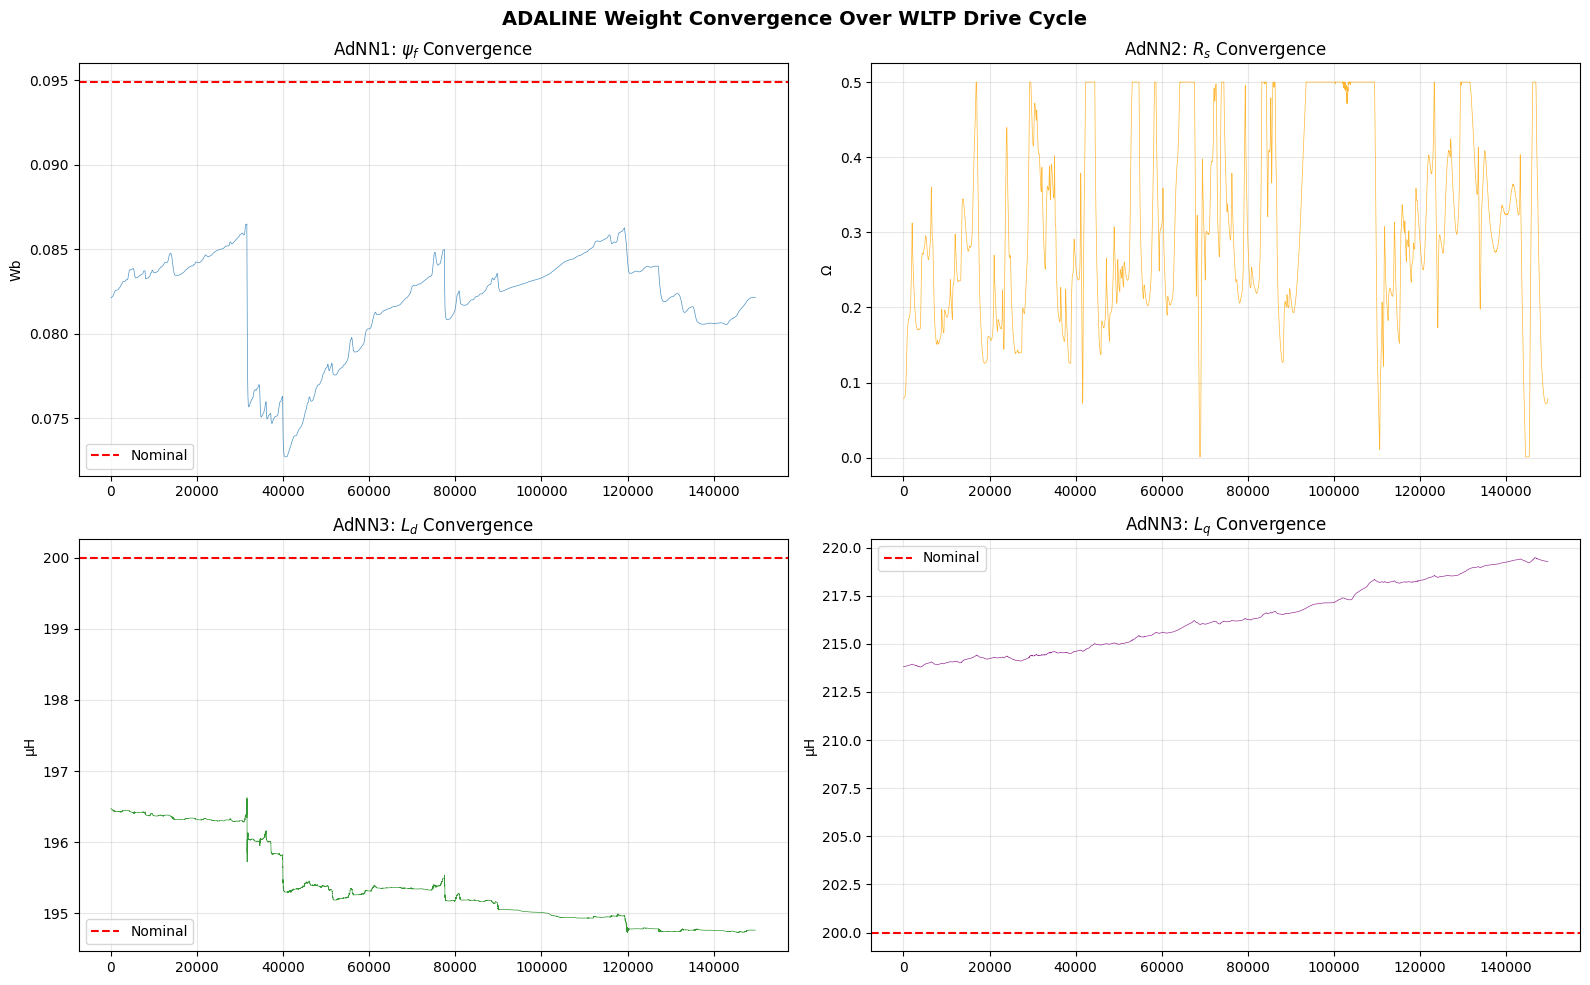

    Saved: convergence_history.csv


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(adaline.history['psi_f'], lw=0.5, alpha=0.8)
ax.axhline(0.0949, color='r', ls='--', label='Nominal'); ax.legend()
ax.set_title('AdNN1: $\psi_f$ Convergence'); ax.set_ylabel('Wb'); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(adaline.history['R_s'], lw=0.5, alpha=0.8, color='orange')
ax.set_title('AdNN2: $R_s$ Convergence'); ax.set_ylabel('Ω'); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(np.array(adaline.history['Ld'])*1e6, lw=0.5, alpha=0.8, color='green')
ax.axhline(200, color='r', ls='--', label='Nominal'); ax.legend()
ax.set_title('AdNN3: $L_d$ Convergence'); ax.set_ylabel('μH'); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(np.array(adaline.history['Lq'])*1e6, lw=0.5, alpha=0.8, color='purple')
ax.axhline(200, color='r', ls='--', label='Nominal'); ax.legend()
ax.set_title('AdNN3: $L_q$ Convergence'); ax.set_ylabel('μH'); ax.grid(True, alpha=0.3)

fig.suptitle('ADALINE Weight Convergence Over WLTP Drive Cycle', fontsize=14, fontweight='bold')
fig.tight_layout()
RC.save_fig(fig, 'FIG_ADALINE_convergence', 'ADALINE Weight Convergence')
plt.show()

# Export convergence history
RC.save_table('convergence_history', pd.DataFrame({
    'psi_f_Wb': adaline.history['psi_f'], 'R_s_Ohm': adaline.history['R_s'],
    'Ld_H': adaline.history['Ld'], 'Lq_H': adaline.history['Lq']
}))


---
## 4. Build Flux Surfaces

The trained model is evaluated on a regular $(i_d, i_q)$ grid to produce
smooth flux linkage surfaces $\psi_d(i_d, i_q)$ and $\psi_q(i_d, i_q)$.
Differential inductances $L_d$ and $L_q$ are computed as the numerical
gradients of the corresponding flux surfaces with respect to the
relevant current axis.

In [9]:
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata

valid = ~np.isnan(psi_d_samples) & ~np.isnan(psi_q_samples)
id_valid, iq_valid = id_arr[valid], iq_arr[valid]
psi_d_valid, psi_q_valid = psi_d_samples[valid], psi_q_samples[valid]
print(f"Valid ADALINE estimates: {valid.sum()} / {len(valid)}")

N_GRID = 30
id_range = np.linspace(id_valid.min(), id_valid.max(), N_GRID)
iq_range = np.linspace(iq_valid.min(), iq_valid.max(), N_GRID)
ID_est, IQ_est = np.meshgrid(id_range, iq_range)

points = np.column_stack([id_valid, iq_valid])
Z_d_est = griddata(points, psi_d_valid, (ID_est, IQ_est), method='linear')
Z_q_est = griddata(points, psi_q_valid, (ID_est, IQ_est), method='linear')
Z_d_nn = griddata(points, psi_d_valid, (ID_est, IQ_est), method='nearest')
Z_q_nn = griddata(points, psi_q_valid, (ID_est, IQ_est), method='nearest')
Z_d_est = np.where(np.isnan(Z_d_est), Z_d_nn, Z_d_est)
Z_q_est = np.where(np.isnan(Z_q_est), Z_q_nn, Z_q_est)
Z_d_est = gaussian_filter(Z_d_est, sigma=1.0)
Z_q_est = gaussian_filter(Z_q_est, sigma=1.0)
Z_d_est = np.clip(Z_d_est, -0.02, 0.12)
Z_q_est = np.clip(Z_q_est, -0.13, 0.13)

d_id, d_iq = id_range[1]-id_range[0], iq_range[1]-iq_range[0]
Ld_est = np.clip(np.gradient(Z_d_est, d_id, axis=1), -2e-3, 2e-3)
Lq_est = np.clip(np.gradient(Z_q_est, d_iq, axis=0), -2e-3, 2e-3)

iq_est_line = np.linspace(0, iq_valid.max(), 200)
psi_pm_est_curve = griddata(points, psi_d_valid, (np.zeros(200), iq_est_line), method='linear')
psi_pm_nn = griddata(points, psi_d_valid, (np.zeros(200), iq_est_line), method='nearest')
psi_pm_est_curve = np.where(np.isnan(psi_pm_est_curve), psi_pm_nn, psi_pm_est_curve)

print(f"ψ_d: [{Z_d_est.min()*1e3:.1f}, {Z_d_est.max()*1e3:.1f}] mWb")
print(f"ψ_q: [{Z_q_est.min()*1e3:.1f}, {Z_q_est.max()*1e3:.1f}] mWb")


Valid ADALINE estimates: 149671 / 149671
ψ_d: [64.7, 88.2] mWb
ψ_q: [-21.5, 47.7] mWb


---
## 5. Torque Reconstruction

The electromagnetic torque predicted from the estimated flux linkages
provides a physics-based consistency check. If $\psi_d$ and $\psi_q$
are accurate, the torque equation
$T_e = \frac{3}{2} p \,(\psi_d\, i_q - \psi_q\, i_d)$
should reproduce the inverter-reported torque closely.

    Saved: FIG_torque_reconstruction.png


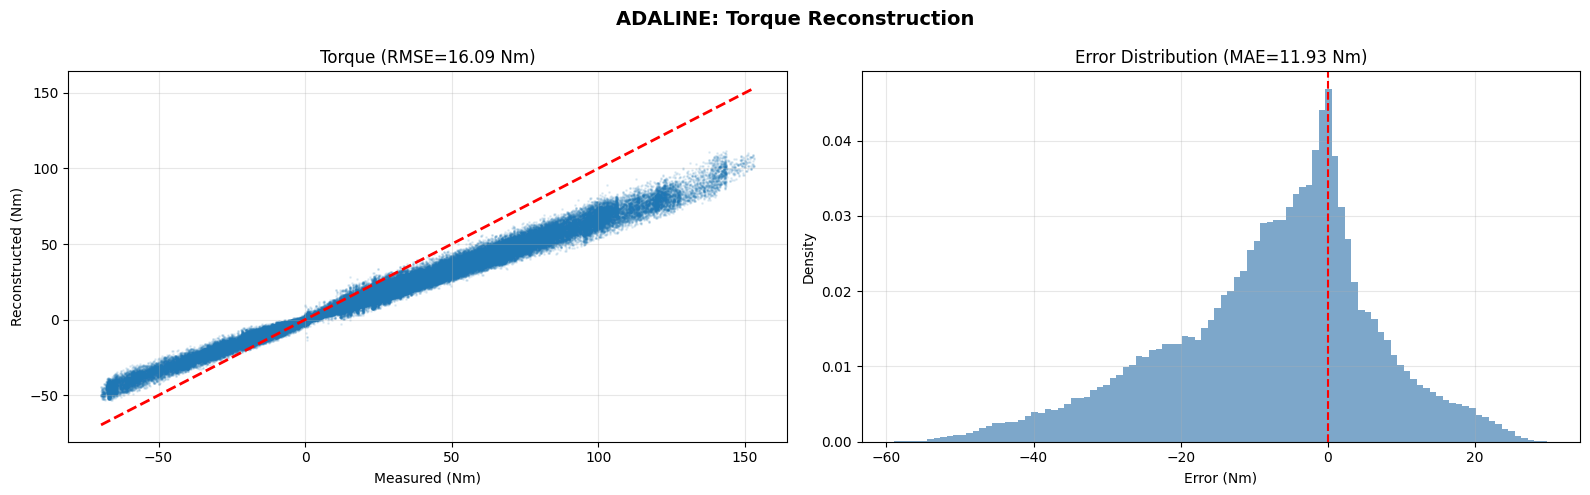

In [10]:
Te_meas = df_train['Te_inv'].values
Te_pred = 1.5 * cfg.pole_pairs * (psi_d_samples * iq_arr - psi_q_samples * id_arr)
valid_te = ~np.isnan(Te_pred)
Te_err = Te_pred[valid_te] - Te_meas[valid_te]
mae = np.mean(np.abs(Te_err))
rmse = np.sqrt(np.mean(Te_err**2))
nrmse = 100 * rmse / 370.0

RC.add_metric('torque_MAE_Nm', mae, 'Nm')
RC.add_metric('torque_RMSE_Nm', rmse, 'Nm')
RC.add_metric('torque_NRMSE_pct', nrmse, '%')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
ax.scatter(Te_meas[valid_te], Te_pred[valid_te], alpha=0.1, s=1)
lims = [min(Te_meas[valid_te].min(), Te_pred[valid_te].min()),
        max(Te_meas[valid_te].max(), Te_pred[valid_te].max())]
ax.plot(lims, lims, 'r--', lw=2); ax.set(xlabel='Measured (Nm)', ylabel='Reconstructed (Nm)')
ax.set_title(f'Torque (RMSE={rmse:.2f} Nm)'); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(Te_err, bins=100, density=True, alpha=0.7, color='steelblue')
ax.axvline(0, color='r', ls='--'); ax.set(xlabel='Error (Nm)', ylabel='Density')
ax.set_title(f'Error Distribution (MAE={mae:.2f} Nm)'); ax.grid(True, alpha=0.3)

fig.suptitle('ADALINE: Torque Reconstruction', fontsize=14, fontweight='bold')
fig.tight_layout()
RC.save_fig(fig, 'FIG_torque_reconstruction', 'Torque Reconstruction Quality')
plt.show()


---
## 6. Reference Comparison — Loading Multi-Speed YASA Data

The YASA P400R was characterised at two speeds for the dq-axis flux
(1000 rpm and 6000 rpm) and two speeds for the PM flux (1000 rpm and
2000 rpm). This section loads all available reference surfaces and
builds interpolators for pointwise comparison against the ADALINE
estimates.

**Why multiple speeds?** The 1000 rpm data is the primary ground truth
because iron-loss distortion is minimal at low speed. The 6000 rpm
data reveals the effect of speed-dependent iron losses on the apparent
flux — the same phenomenon that the WLTP estimate (which spans a wide
speed range) is expected to capture as an averaged effect.

In [11]:
# ============================================================================
#  Load reference data & build interpolators (multi-speed)
# ============================================================================
import numpy as np, pandas as pd
from scipy.interpolate import RegularGridInterpolator

ref_files = cfg.get_reference_files()

# ── Helper: build interpolators from a dq reference DataFrame ──
def build_dq_interpolators(df):
    id_grid = np.sort(df['id_A'].unique())
    iq_grid = np.sort(df['iq_A'].unique())
    piv_d = df.pivot_table(index='id_A', columns='iq_A', values='psi_d_Wb').sort_index()
    piv_q = df.pivot_table(index='id_A', columns='iq_A', values='psi_q_Wb').sort_index()
    interp_d = RegularGridInterpolator(
        (id_grid, iq_grid), piv_d.values, bounds_error=False, fill_value=None)
    interp_q = RegularGridInterpolator(
        (id_grid, iq_grid), piv_q.values, bounds_error=False, fill_value=None)
    return id_grid, iq_grid, interp_d, interp_q

# ── 1000 rpm reference (primary — used for pointwise error metrics) ──
ref_dq_1k = pd.read_csv(ref_files['map_file_1000rpm'])
id_ref_1k, iq_ref_1k, interp_d_1k, interp_q_1k = build_dq_interpolators(ref_dq_1k)
print(f"1000 rpm reference: {len(ref_dq_1k)} nodes, "
      f"id=[{id_ref_1k[0]:.0f}, {id_ref_1k[-1]:.0f}], "
      f"iq=[{iq_ref_1k[0]:.0f}, {iq_ref_1k[-1]:.0f}]")

# ── 6000 rpm reference (secondary — overlay for comparison) ──
has_6k = ref_files['map_file_6000rpm'].exists()
if has_6k:
    ref_dq_6k = pd.read_csv(ref_files['map_file_6000rpm'])
    id_ref_6k, iq_ref_6k, interp_d_6k, interp_q_6k = build_dq_interpolators(ref_dq_6k)
    print(f"6000 rpm reference: {len(ref_dq_6k)} nodes, "
          f"id=[{id_ref_6k[0]:.0f}, {id_ref_6k[-1]:.0f}], "
          f"iq=[{iq_ref_6k[0]:.0f}, {iq_ref_6k[-1]:.0f}]")
else:
    print("6000 rpm reference: not found (comparison will be omitted)")

# ── PM flux reference (1000 rpm + 2000 rpm curves in one file) ──
ref_pm = pd.read_csv(ref_files['pm_file'])
iq_pm_grid = ref_pm['iq_grid'].values

has_pm_1k = 'psi_pm_Wb' in ref_pm.columns and ref_pm['psi_pm_Wb'].notna().any()
has_pm_2k = 'psi_pm_2000rpm_Wb' in ref_pm.columns and ref_pm['psi_pm_2000rpm_Wb'].notna().any()

psi_pm_ref_1k = ref_pm['psi_pm_Wb'].values if has_pm_1k else None
psi_pm_ref_2k = ref_pm['psi_pm_2000rpm_Wb'].values if has_pm_2k else None
# Back-compat alias used by existing comparison cells
psi_pm_ref_vals = psi_pm_ref_1k if psi_pm_ref_1k is not None else psi_pm_ref_2k

# Also keep the legacy single-speed aliases for the metrics code
id_ref_grid, iq_ref_grid = id_ref_1k, iq_ref_1k
interp_psi_d_ref, interp_psi_q_ref = interp_d_1k, interp_q_1k

print(f"PM flux: {len(iq_pm_grid)} points | "
      f"1000 rpm={'YES' if has_pm_1k else 'NO'} | "
      f"2000 rpm={'YES' if has_pm_2k else 'NO'}")


1000 rpm reference: 10201 nodes, id=[-200, 0], iq=[0, 600]
6000 rpm reference: 10201 nodes, id=[-200, 0], iq=[0, 600]
PM flux: 240 points | 1000 rpm=YES | 2000 rpm=YES


### 6.1 Build Comparison Surfaces

The ADALINE estimated grids are interpolated onto the reference
grid for pointwise error computation. Error metrics (MAE, RMSE) are
computed separately against both the 1000 rpm and 6000 rpm references
so the reader can judge where the estimate sits relative to each
physical regime.

In [12]:
# ============================================================================
#  Build comparison surfaces on the estimated grid
# ============================================================================

# ── Primary reference (1000 rpm) — pointwise comparison on the estimation grid ──
ID_cl = np.clip(ID_est, id_ref_1k.min(), id_ref_1k.max())
IQ_cl = np.clip(IQ_est, iq_ref_1k.min(), iq_ref_1k.max())

PSI_D_ref_1k = interp_d_1k(np.column_stack([ID_cl.ravel(), IQ_cl.ravel()])).reshape(ID_est.shape)
PSI_Q_ref_1k = interp_q_1k(np.column_stack([ID_cl.ravel(), IQ_cl.ravel()])).reshape(ID_est.shape)

# ── Secondary reference (6000 rpm) — overlay only ──
if has_6k:
    ID_cl6 = np.clip(ID_est, id_ref_6k.min(), id_ref_6k.max())
    IQ_cl6 = np.clip(IQ_est, iq_ref_6k.min(), iq_ref_6k.max())
    PSI_D_ref_6k = interp_d_6k(np.column_stack([ID_cl6.ravel(), IQ_cl6.ravel()])).reshape(ID_est.shape)
    PSI_Q_ref_6k = interp_q_6k(np.column_stack([ID_cl6.ravel(), IQ_cl6.ravel()])).reshape(ID_est.shape)

# ── Differential inductance from the 1000 rpm reference ──
DELTA = 0.5
ID_cl_p = np.clip(ID_est + DELTA, id_ref_1k.min(), id_ref_1k.max())
ID_cl_m = np.clip(ID_est - DELTA, id_ref_1k.min(), id_ref_1k.max())
IQ_cl_p = np.clip(IQ_est + DELTA, iq_ref_1k.min(), iq_ref_1k.max())
IQ_cl_m = np.clip(IQ_est - DELTA, iq_ref_1k.min(), iq_ref_1k.max())

pd_ref_p = interp_d_1k(np.column_stack([ID_cl_p.ravel(), IQ_cl.ravel()])).reshape(ID_est.shape)
pd_ref_m = interp_d_1k(np.column_stack([ID_cl_m.ravel(), IQ_cl.ravel()])).reshape(ID_est.shape)
pq_ref_p = interp_q_1k(np.column_stack([ID_cl.ravel(), IQ_cl_p.ravel()])).reshape(ID_est.shape)
pq_ref_m = interp_q_1k(np.column_stack([ID_cl.ravel(), IQ_cl_m.ravel()])).reshape(ID_est.shape)

delta_id_eff = ID_cl_p - ID_cl_m
delta_iq_eff = IQ_cl_p - IQ_cl_m
Ld_ref = np.where(np.abs(delta_id_eff) > 0.01, (pd_ref_p - pd_ref_m) / delta_id_eff, np.nan)
Lq_ref = np.where(np.abs(delta_iq_eff) > 0.01, (pq_ref_p - pq_ref_m) / delta_iq_eff, np.nan)

_DOMAIN = (ID_est >= -100) & (ID_est <= 0) & (IQ_est >= 0) & (IQ_est <= 200)

# ── Back-compat aliases ──
PSI_D_ref = PSI_D_ref_1k
PSI_Q_ref = PSI_Q_ref_1k

# ── Error metrics vs 1000 rpm primary reference ──
valid_mask = _DOMAIN & ~np.isnan(PSI_D_ref_1k) & ~np.isnan(PSI_Q_ref_1k)
if valid_mask.any():
    ed = Z_d_est[valid_mask] - PSI_D_ref_1k[valid_mask]
    eq = Z_q_est[valid_mask] - PSI_Q_ref_1k[valid_mask]
    RC.add_metric('psi_d_MAE_mWb_1k',  np.mean(np.abs(ed))*1e3,  'mWb')
    RC.add_metric('psi_d_RMSE_mWb_1k', np.sqrt(np.mean(ed**2))*1e3, 'mWb')
    RC.add_metric('psi_q_MAE_mWb_1k',  np.mean(np.abs(eq))*1e3,  'mWb')
    RC.add_metric('psi_q_RMSE_mWb_1k', np.sqrt(np.mean(eq**2))*1e3, 'mWb')

# ── Error metrics vs 6000 rpm secondary reference ──
if has_6k:
    valid_6k = _DOMAIN & ~np.isnan(PSI_D_ref_6k) & ~np.isnan(PSI_Q_ref_6k)
    if valid_6k.any():
        ed6 = Z_d_est[valid_6k] - PSI_D_ref_6k[valid_6k]
        eq6 = Z_q_est[valid_6k] - PSI_Q_ref_6k[valid_6k]
        RC.add_metric('psi_d_MAE_mWb_6k',  np.mean(np.abs(ed6))*1e3,  'mWb')
        RC.add_metric('psi_d_RMSE_mWb_6k', np.sqrt(np.mean(ed6**2))*1e3, 'mWb')
        RC.add_metric('psi_q_MAE_mWb_6k',  np.mean(np.abs(eq6))*1e3,  'mWb')
        RC.add_metric('psi_q_RMSE_mWb_6k', np.sqrt(np.mean(eq6**2))*1e3, 'mWb')

# ── Export ──
export = pd.DataFrame({
    'Id_A': ID_est.ravel(), 'Iq_A': IQ_est.ravel(),
    'psi_d_est_Wb': Z_d_est.ravel(), 'psi_q_est_Wb': Z_q_est.ravel(),
    'psi_d_ref_1k_Wb': PSI_D_ref_1k.ravel(), 'psi_q_ref_1k_Wb': PSI_Q_ref_1k.ravel(),
    'Ld_est_H': Ld_est.ravel(), 'Lq_est_H': Lq_est.ravel(),
    'Ld_ref_H': Ld_ref.ravel(), 'Lq_ref_H': Lq_ref.ravel(),
})
if has_6k:
    export['psi_d_ref_6k_Wb'] = PSI_D_ref_6k.ravel()
    export['psi_q_ref_6k_Wb'] = PSI_Q_ref_6k.ravel()
RC.save_table('flux_surfaces', export)

print('\nFlux Error vs Reference (within domain):')
for k, v in RC.metrics.items():
    if 'psi' in k:
        print(f"  {k}: {v['value']:.2f} {v['unit']}")


    Saved: flux_surfaces.csv

Flux Error vs Reference (within domain):
  psi_f_final_Wb: 0.08 Wb
  psi_d_MAE_mWb_1k: 12.86 mWb
  psi_d_RMSE_mWb_1k: 13.81 mWb
  psi_q_MAE_mWb_1k: 7.42 mWb
  psi_q_RMSE_mWb_1k: 8.42 mWb
  psi_d_MAE_mWb_6k: 21.50 mWb
  psi_d_RMSE_mWb_6k: 27.33 mWb
  psi_q_MAE_mWb_6k: 10.06 mWb
  psi_q_RMSE_mWb_6k: 10.29 mWb


---
## 7. PM Flux Validation — 1000 rpm & 2000 rpm

The PM flux $\psi_{PM}(i_q)$ is the d-axis flux evaluated along the
$i_d = 0$ line. It captures the permanent-magnet contribution and its
variation with q-axis saturation. Comparing the ADALINE estimate
against both the 1000 rpm and 2000 rpm YASA curves reveals whether the
transient-data estimate lies between the two speed regimes, as expected
from WLTP's broad speed content.

    Saved: FIG_pm_flux_multispeed.png


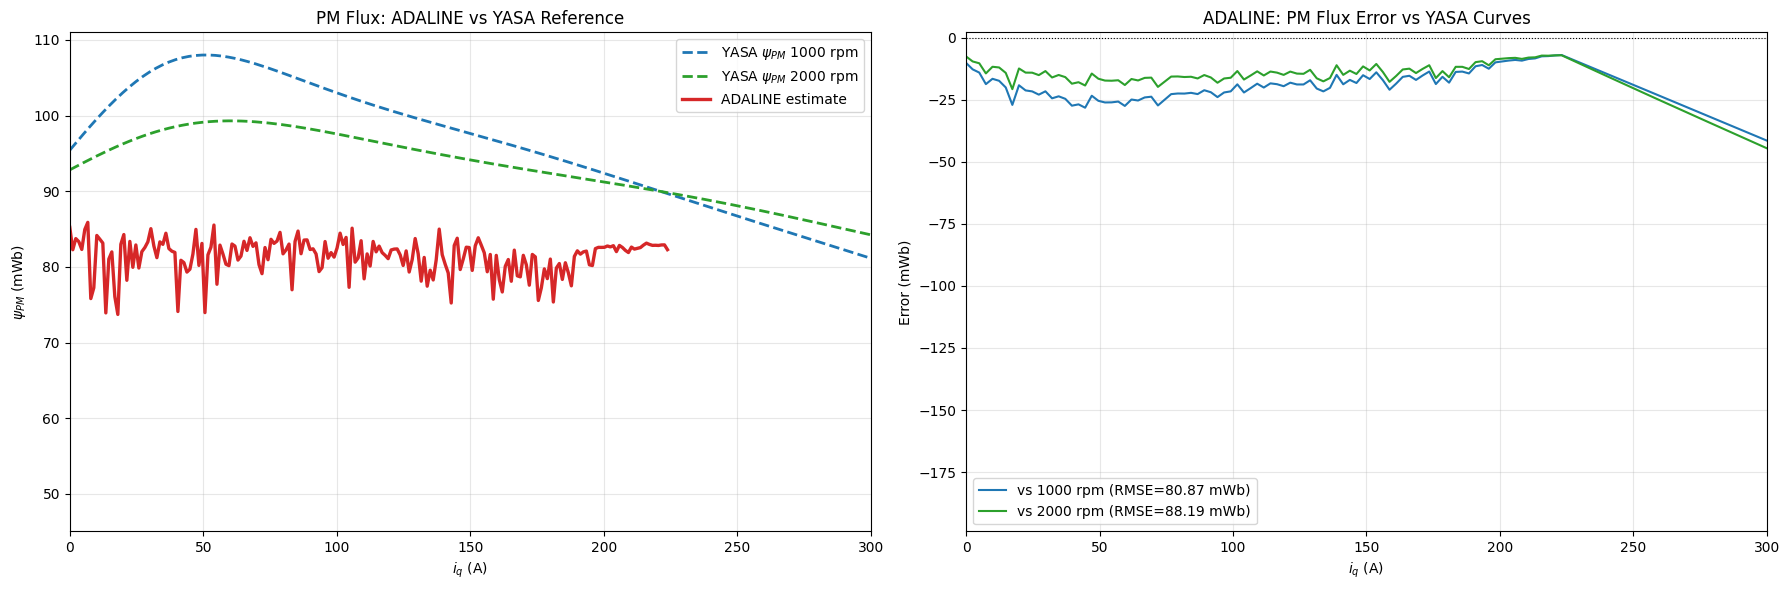

    Saved: pm_flux_comparison.csv


In [13]:
# ============================================================================
#  PM Flux Comparison: estimate vs YASA 1000 rpm & 2000 rpm
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ---- Panel 1: PM flux curves ----
ax = axes[0]
if has_pm_1k:
    ax.plot(iq_pm_grid, psi_pm_ref_1k*1e3, color='tab:blue', ls='--', lw=2.0,
            label=r'YASA $\psi_{PM}$ 1000 rpm')
if has_pm_2k:
    ax.plot(iq_pm_grid, psi_pm_ref_2k*1e3, color='tab:green', ls='--', lw=2.0,
            label=r'YASA $\psi_{PM}$ 2000 rpm')
ax.plot(iq_est_line, psi_pm_est_curve*1e3, color='tab:red', ls='-', lw=2.4,
        label=f'{METHOD_LABEL} estimate')
ax.set(xlabel=r'$i_q$ (A)', ylabel=r'$\psi_{PM}$ (mWb)',
       title=f'PM Flux: {METHOD_LABEL} vs YASA Reference')
ax.legend(); ax.set_xlim([0, 300]); ax.grid(True, alpha=0.3)

# ---- Panel 2: PM-flux error against each speed curve ----
ax = axes[1]
# Interpolate estimate onto the reference iq grid for error computation
from scipy.interpolate import interp1d
est_interp = interp1d(iq_est_line, psi_pm_est_curve, bounds_error=False, fill_value='extrapolate')
psi_pm_est_on_grid = est_interp(iq_pm_grid)

if has_pm_1k:
    err_1k = (psi_pm_est_on_grid - psi_pm_ref_1k) * 1e3
    ax.plot(iq_pm_grid, err_1k, color='tab:blue', lw=1.5,
            label=f'vs 1000 rpm (RMSE={np.sqrt(np.nanmean(err_1k**2)):.2f} mWb)')
    RC.add_metric('psi_pm_RMSE_mWb_1k', np.sqrt(np.nanmean(err_1k**2)), 'mWb')
if has_pm_2k:
    err_2k = (psi_pm_est_on_grid - psi_pm_ref_2k) * 1e3
    ax.plot(iq_pm_grid, err_2k, color='tab:green', lw=1.5,
            label=f'vs 2000 rpm (RMSE={np.sqrt(np.nanmean(err_2k**2)):.2f} mWb)')
    RC.add_metric('psi_pm_RMSE_mWb_2k', np.sqrt(np.nanmean(err_2k**2)), 'mWb')
ax.axhline(0, color='k', ls=':', lw=0.8)
ax.set(xlabel=r'$i_q$ (A)', ylabel='Error (mWb)',
       title=f'{METHOD_LABEL}: PM Flux Error vs YASA Curves')
ax.legend(); ax.set_xlim([0, 300]); ax.grid(True, alpha=0.3)

fig.tight_layout()
RC.save_fig(fig, 'FIG_pm_flux_multispeed', f'{METHOD_LABEL}: PM Flux Multi-Speed Comparison')
plt.show()

RC.save_table('pm_flux_comparison', pd.DataFrame({
    'iq_A': iq_est_line, 'psi_pm_est_Wb': psi_pm_est_curve
}))


---
## 8. Flux Surfaces — Estimated vs YASA 1000 rpm & 6000 rpm

Three-panel 3D surface plots for each flux axis: the ADALINE
estimate alongside both YASA reference speeds. This visualisation
makes the speed-dependent flux depression immediately apparent —
the 6000 rpm surfaces sit lower than the 1000 rpm surfaces due to
uncompensated iron losses.

    Saved: FIG_psi_d_multispeed.png


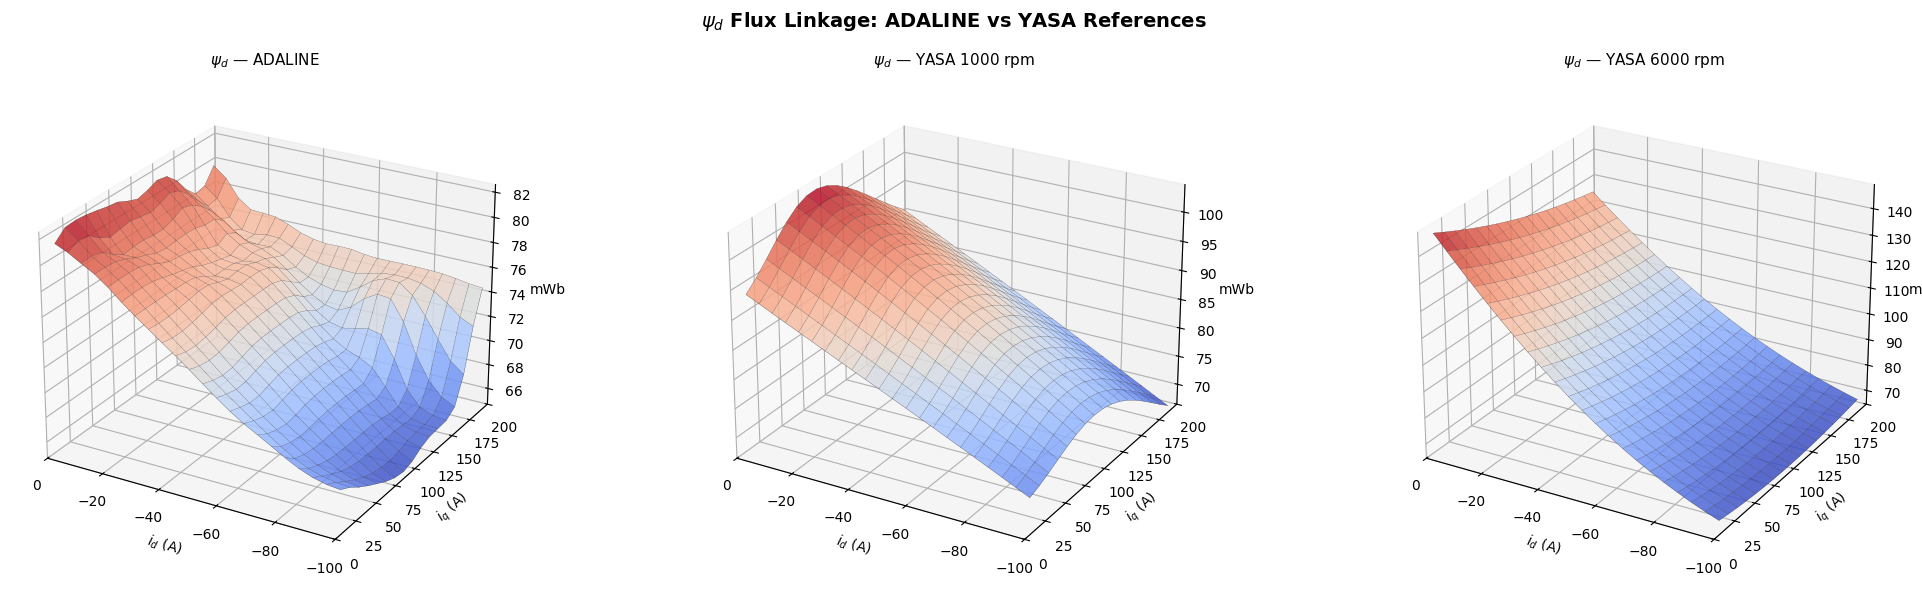

    Saved: FIG_psi_q_multispeed.png


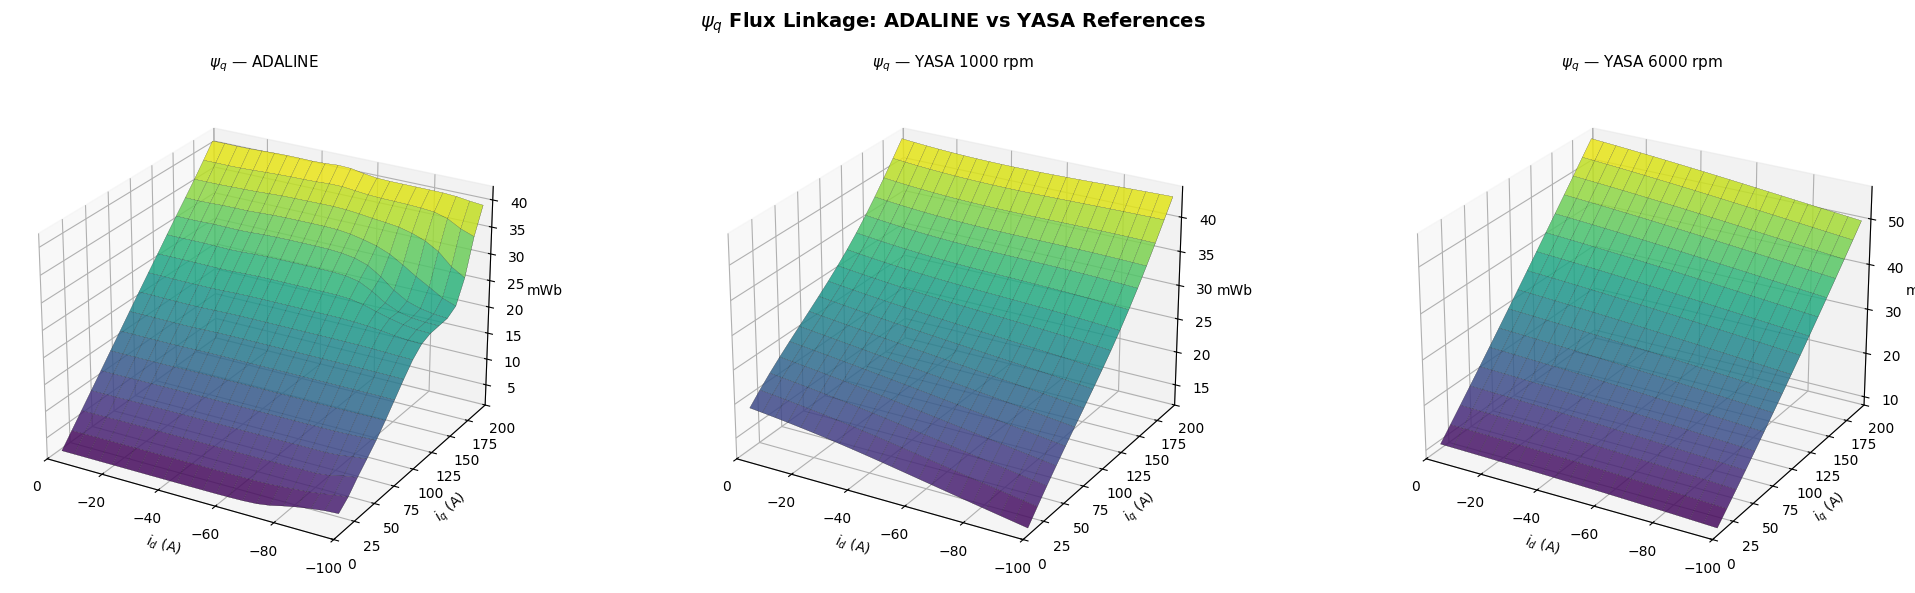

In [14]:
# ============================================================================
#  Flux Surfaces: Estimated vs YASA 1000 rpm vs YASA 6000 rpm
# ============================================================================
from mpl_toolkits.mplot3d import Axes3D

_domain = (ID_est >= -100) & (ID_est <= 0) & (IQ_est >= 0) & (IQ_est <= 200)
n_cols = 3 if has_6k else 2

for axis_label, Z_est, Z_1k, Z_6k, cmap in [
    (r'$\psi_d$', Z_d_est, PSI_D_ref_1k, PSI_D_ref_6k if has_6k else None, 'coolwarm'),
    (r'$\psi_q$', Z_q_est, PSI_Q_ref_1k, PSI_Q_ref_6k if has_6k else None, 'viridis'),
]:
    fig = plt.figure(figsize=(7*n_cols, 6))
    panels = [
        (Z_est, f'{axis_label} — {METHOD_LABEL}'),
        (Z_1k,  f'{axis_label} — YASA 1000 rpm'),
    ]
    if Z_6k is not None:
        panels.append((Z_6k, f'{axis_label} — YASA 6000 rpm'))

    for idx, (z_raw, title) in enumerate(panels):
        ax = fig.add_subplot(1, n_cols, idx + 1, projection='3d')
        valid = ~np.isnan(z_raw) & _domain
        ax.plot_surface(ID_est, IQ_est, np.where(valid, z_raw, np.nan)*1e3,
                        cmap=cmap, alpha=0.85, edgecolor='k', linewidth=0.1)
        ax.set_xlabel('$i_d$ (A)'); ax.set_ylabel('$i_q$ (A)')
        ax.set_zlabel('mWb')
        ax.set_title(title, fontsize=11)
        ax.set_xlim(0, -100); ax.set_ylim(0, 200); ax.view_init(25, -60)

    fig.suptitle(f'{axis_label} Flux Linkage: {METHOD_LABEL} vs YASA References',
                 fontweight='bold', fontsize=14)
    fig.tight_layout()
    tag = 'd' if 'psi_d' in axis_label or 'd' in axis_label else 'q'
    RC.save_fig(fig, f'FIG_psi_{tag}_multispeed',
                f'{METHOD_LABEL}: {axis_label} Multi-Speed Comparison')
    plt.show()


### 8.1 Error Heatmaps at Both Reference Speeds

Contour plots of the pointwise error $(\hat{\psi} - \psi_{ref})$
on the estimation grid. The upper row shows the error against the
1000 rpm reference; the lower row shows the error against the 6000 rpm
reference. Signed error reveals systematic bias; warm colours indicate
over-estimation, cool colours under-estimation.

    Saved: FIG_error_heatmaps_multispeed.png


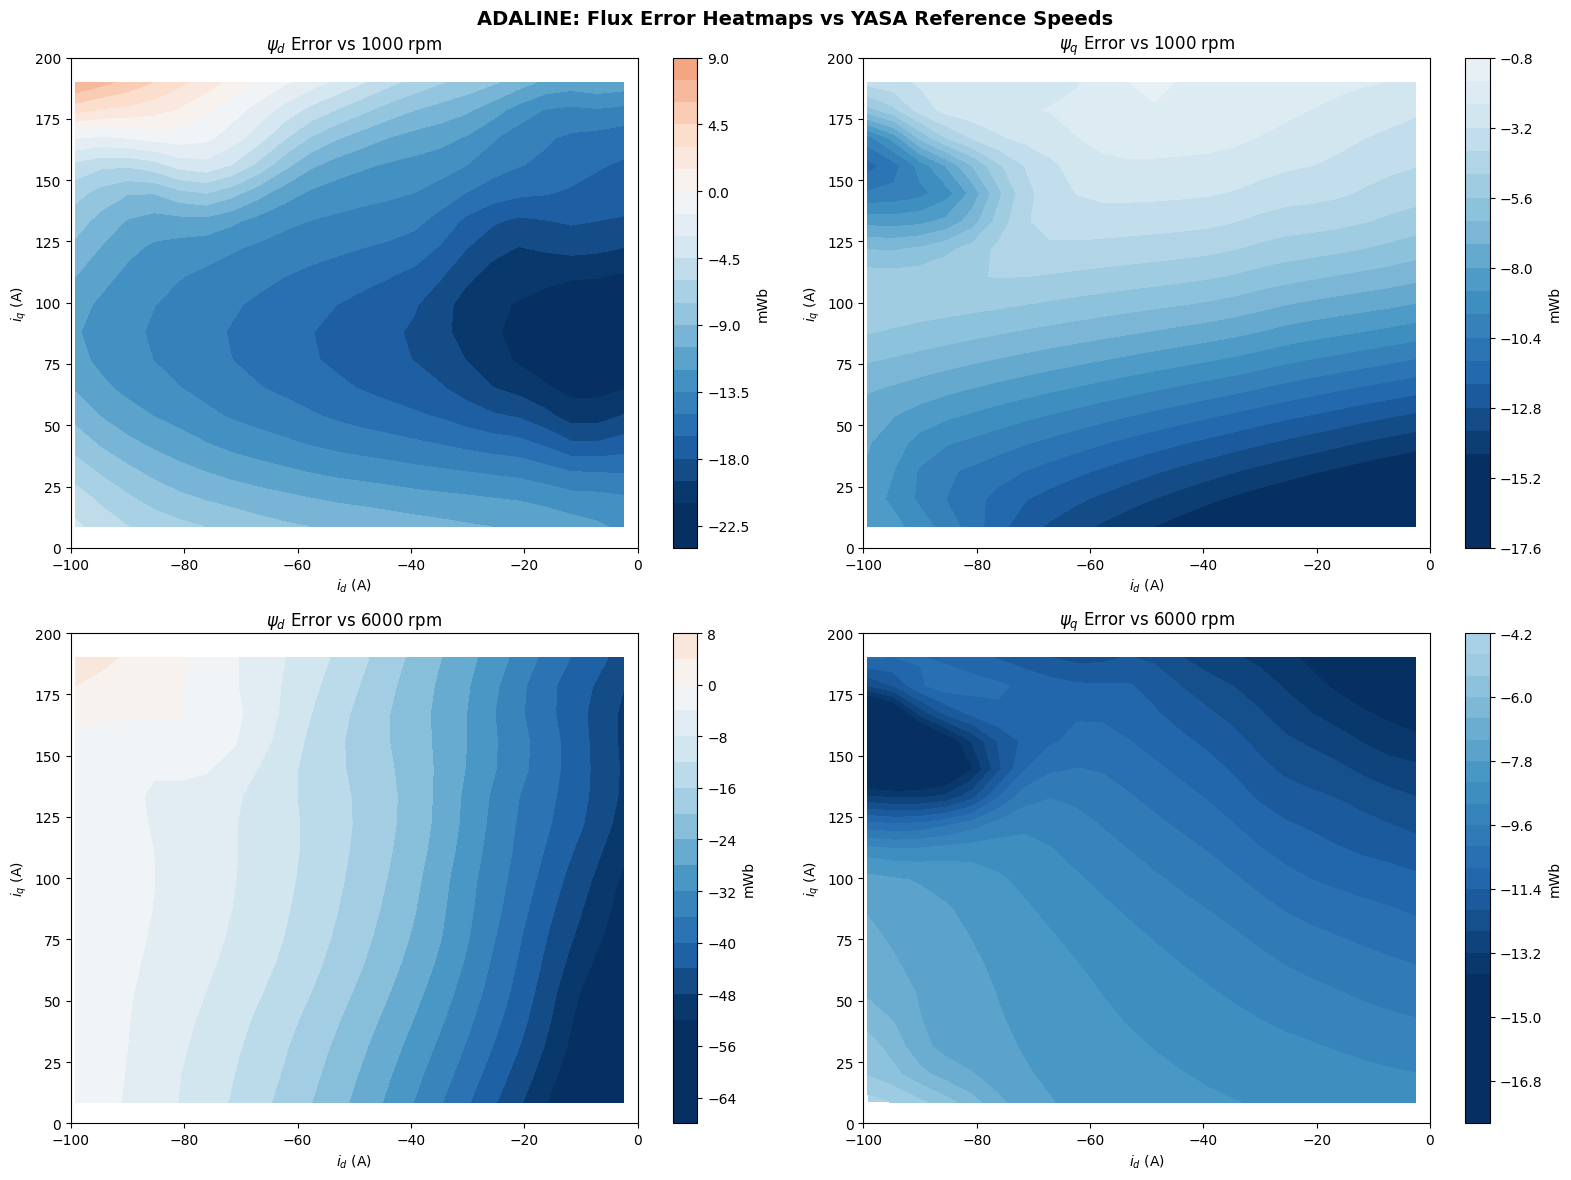

In [15]:
# ============================================================================
#  Error Heatmaps: ψ_d and ψ_q error vs 1000 rpm and 6000 rpm references
# ============================================================================

n_rows = 2 if has_6k else 1
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 6*n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for col, (Z_est_ax, Z_ref_1k_ax, Z_ref_6k_ax, label) in enumerate([
    (Z_d_est, PSI_D_ref_1k, PSI_D_ref_6k if has_6k else None, r'$\psi_d$'),
    (Z_q_est, PSI_Q_ref_1k, PSI_Q_ref_6k if has_6k else None, r'$\psi_q$'),
]):
    # Row 0: error vs 1000 rpm
    err_1k = (Z_est_ax - Z_ref_1k_ax) * 1e3
    err_1k_masked = np.where(_DOMAIN, err_1k, np.nan)
    vmax = np.nanpercentile(np.abs(err_1k_masked), 95)
    if np.isnan(vmax) or vmax < 0.1: vmax = 10
    ax = axes[0, col]
    cf = ax.contourf(ID_est, IQ_est, err_1k_masked, levels=21, cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax)
    plt.colorbar(cf, ax=ax, label='mWb')
    ax.set(xlabel='$i_d$ (A)', ylabel='$i_q$ (A)',
           title=f'{label} Error vs 1000 rpm')
    ax.set_xlim(-100, 0); ax.set_ylim(0, 200)

    # Row 1: error vs 6000 rpm (if available)
    if has_6k and Z_ref_6k_ax is not None:
        err_6k = (Z_est_ax - Z_ref_6k_ax) * 1e3
        err_6k_masked = np.where(_DOMAIN, err_6k, np.nan)
        vmax6 = np.nanpercentile(np.abs(err_6k_masked), 95)
        if np.isnan(vmax6) or vmax6 < 0.1: vmax6 = 10
        ax = axes[1, col]
        cf = ax.contourf(ID_est, IQ_est, err_6k_masked, levels=21, cmap='RdBu_r',
                         vmin=-vmax6, vmax=vmax6)
        plt.colorbar(cf, ax=ax, label='mWb')
        ax.set(xlabel='$i_d$ (A)', ylabel='$i_q$ (A)',
               title=f'{label} Error vs 6000 rpm')
        ax.set_xlim(-100, 0); ax.set_ylim(0, 200)

fig.suptitle(f'{METHOD_LABEL}: Flux Error Heatmaps vs YASA Reference Speeds',
             fontweight='bold', fontsize=14)
fig.tight_layout()
RC.save_fig(fig, 'FIG_error_heatmaps_multispeed',
            f'{METHOD_LABEL}: Multi-Speed Error Heatmaps')
plt.show()


---
## 9. Differential Inductance Comparison

Differential inductances are computed as numerical gradients of the
flux surfaces: $L_d = \partial\psi_d / \partial i_d$ and
$L_q = \partial\psi_q / \partial i_q$. The reference inductances
are derived from the 1000 rpm YASA surfaces using the same finite-difference
scheme.

    Saved: FIG_inductance_comparison.png


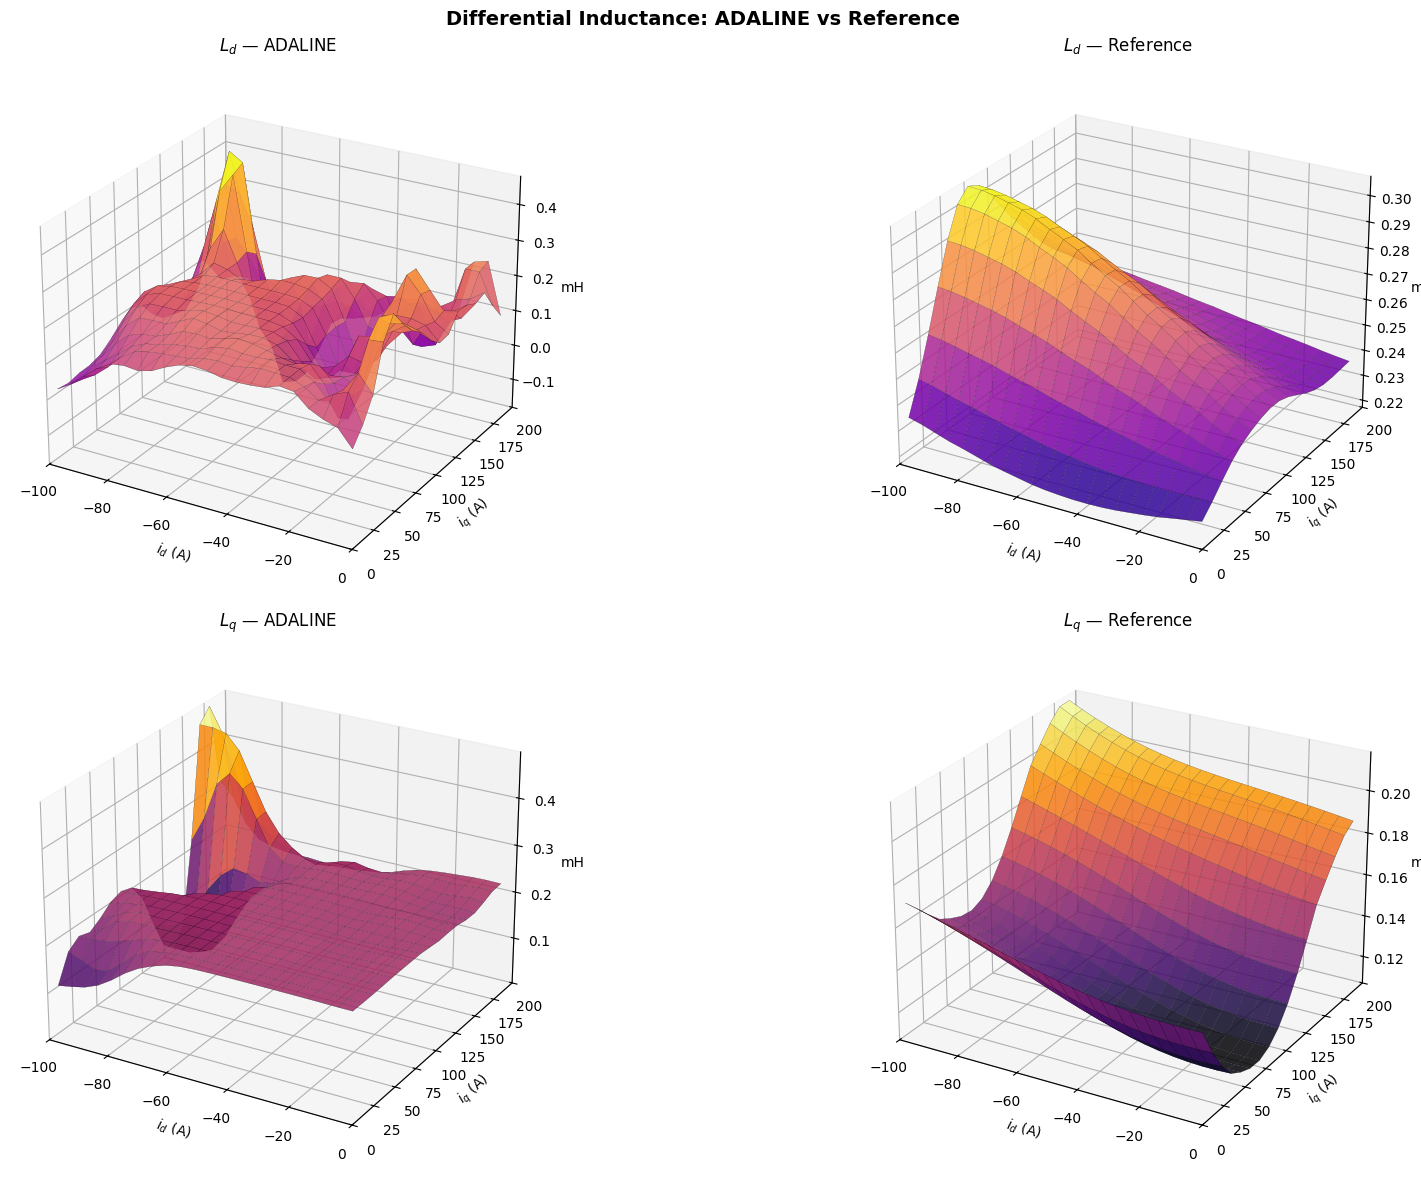

In [16]:
# ============================================================================
#  Figures: Ld and Lq — Estimated vs Reference (saved)
# ============================================================================
L_MIN, L_MAX = -2e-3, 2e-3
Ld_est_c = np.clip(Ld_est, L_MIN, L_MAX)
Lq_est_c = np.clip(Lq_est, L_MIN, L_MAX)
Ld_ref_c = np.clip(Ld_ref, L_MIN, L_MAX)
Lq_ref_c = np.clip(Lq_ref, L_MIN, L_MAX)

fig = plt.figure(figsize=(20, 12))
for k, (data, ttl, cmap) in enumerate([
    (Ld_est_c, f'$L_d$ — {METHOD_LABEL}', 'plasma'),
    (Ld_ref_c, '$L_d$ — Reference', 'plasma'),
    (Lq_est_c, f'$L_q$ — {METHOD_LABEL}', 'inferno'),
    (Lq_ref_c, '$L_q$ — Reference', 'inferno'),
]):
    ax = fig.add_subplot(2, 2, k+1, projection='3d')
    valid = ~np.isnan(data) & _DOMAIN
    ax.plot_surface(ID_est, IQ_est, np.where(valid, data, np.nan)*1e3,
                    cmap=cmap, alpha=0.85, edgecolor='k', linewidth=0.1)
    ax.set(xlabel='$i_d$ (A)', ylabel='$i_q$ (A)', zlabel='mH')
    ax.set_title(ttl); ax.set_xlim(-100, 0); ax.set_ylim(0, 200); ax.view_init(25, -60)
fig.suptitle(f'Differential Inductance: {METHOD_LABEL} vs Reference',
             fontweight='bold', fontsize=14)
fig.tight_layout()
RC.save_fig(fig, 'FIG_inductance_comparison',
            f'{METHOD_LABEL}: Differential Inductance vs Reference')
plt.show()

# Export inductance error metrics
valid_L = _DOMAIN & ~np.isnan(Ld_ref) & ~np.isnan(Lq_ref)
if valid_L.any():
    eld = Ld_est[valid_L] - Ld_ref[valid_L]
    elq = Lq_est[valid_L] - Lq_ref[valid_L]
    RC.add_metric('Ld_MAE_uH',  np.mean(np.abs(eld))*1e6, 'μH')
    RC.add_metric('Ld_RMSE_uH', np.sqrt(np.mean(eld**2))*1e6, 'μH')
    RC.add_metric('Lq_MAE_uH',  np.mean(np.abs(elq))*1e6, 'μH')
    RC.add_metric('Lq_RMSE_uH', np.sqrt(np.mean(elq**2))*1e6, 'μH')


---
## 10. Summary Metrics

In [17]:
# ============================================================================
#  Summary Metrics Table
# ============================================================================

print(f"\n{'='*70}")
print(f" {METHOD_LABEL} ESTIMATION — ERROR SUMMARY vs YASA REFERENCES")
print(f"{'='*70}")
print(f"{'Metric':<35} {'Value':>10} {'Unit':>8}")
print(f"{'-'*70}")
for k, v in RC.metrics.items():
    print(f"  {k:<33} {v['value']:>10.3f} {v['unit']:>8}")
print(f"{'='*70}")



 ADALINE ESTIMATION — ERROR SUMMARY vs YASA REFERENCES
Metric                                   Value     Unit
----------------------------------------------------------------------
  psi_f_final_Wb                         0.082       Wb
  R_s_final_Ohm                          0.079        Ω
  Ld_final_uH                          194.765       μH
  Lq_final_uH                          219.269       μH
  torque_MAE_Nm                         11.931       Nm
  torque_RMSE_Nm                        16.087       Nm
  torque_NRMSE_pct                       4.348        %
  psi_d_MAE_mWb_1k                      12.855      mWb
  psi_d_RMSE_mWb_1k                     13.810      mWb
  psi_q_MAE_mWb_1k                       7.421      mWb
  psi_q_RMSE_mWb_1k                      8.417      mWb
  psi_d_MAE_mWb_6k                      21.502      mWb
  psi_d_RMSE_mWb_6k                     27.325      mWb
  psi_q_MAE_mWb_6k                      10.056      mWb
  psi_q_RMSE_mWb_6k              

---
## 11. Report Generation

Assemble all figures, metrics, and exported CSVs into a self-contained
Word document for inclusion in the thesis appendix.

In [18]:
# ============================================================================
#  GENERATE .docx REPORT — pure python-docx, no Node.js required
# ============================================================================
import sys, subprocess as _sp
_sp.run([sys.executable, '-m', 'pip', 'install', 'python-docx', '-q'], check=True)

from docx import Document
from docx.shared import Pt, Cm, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
from docx.enum.table import WD_TABLE_ALIGNMENT

summary = RC.export_summary_json()
report_docx = cfg.results_dir / f'{METHOD_LABEL}_Report.docx'
doc = Document()

for section in doc.sections:
    section.top_margin = section.bottom_margin = Cm(2.5)
    section.left_margin = section.right_margin = Cm(2.5)
doc.styles['Normal'].font.name = 'Arial'
doc.styles['Normal'].font.size = Pt(11)

def shade_cell(cell, fill_hex):
    tcPr = cell._tc.get_or_add_tcPr()
    shd = OxmlElement('w:shd')
    shd.set(qn('w:val'), 'clear'); shd.set(qn('w:color'), 'auto')
    shd.set(qn('w:fill'), fill_hex); tcPr.append(shd)

def add_heading(doc, text, level=1):
    p = doc.add_heading(text, level=level)
    run = p.runs[0] if p.runs else p.add_run(text)
    run.font.color.rgb = RGBColor(0x2E,0x40,0x57) if level==1 else RGBColor(0x3A,0x6B,0x8C)
    run.font.name = 'Arial'; return p

def add_para(doc, text, bold=False, size=11):
    p = doc.add_paragraph(); run = p.add_run(text)
    run.bold = bold; run.font.name = 'Arial'; run.font.size = Pt(size); return p

# Title page
doc.add_paragraph(); doc.add_paragraph()
tp = doc.add_paragraph(); tp.alignment = WD_ALIGN_PARAGRAPH.CENTER
tr = tp.add_run(f'{METHOD_LABEL} Parameter Estimation')
tr.bold = True; tr.font.size = Pt(24); tr.font.color.rgb = RGBColor(0x2E,0x40,0x57)
sp = doc.add_paragraph(); sp.alignment = WD_ALIGN_PARAGRAPH.CENTER
sp.add_run('Axial Flux Permanent Magnet Synchronous Machine').font.size = Pt(14)
sp2 = doc.add_paragraph(); sp2.alignment = WD_ALIGN_PARAGRAPH.CENTER
r2 = sp2.add_run('YASA-type IPMSM — 4 Pole Pairs — 370 Nm Peak')
r2.font.size = Pt(11); r2.font.color.rgb = RGBColor(0x88,0x88,0x88)
dp = doc.add_paragraph(); dp.alignment = WD_ALIGN_PARAGRAPH.CENTER
dp.add_run(f"Generated: {datetime.now().strftime('%Y-%m-%d')}").font.size = Pt(10)
doc.add_page_break()

# Section 1: Metrics table
add_heading(doc, '1. Estimation Accuracy Summary', level=1)
add_para(doc, f'Error metrics between {METHOD_LABEL} estimated surfaces and GPR reference.')
doc.add_paragraph()
metric_rows = [{'Parameter': k, 'Value': f"{v['value']:.4f}", 'Unit': v['unit']}
               for k, v in RC.metrics.items()]
tbl = doc.add_table(rows=1+len(metric_rows), cols=3)
tbl.alignment = WD_TABLE_ALIGNMENT.CENTER; tbl.style = 'Table Grid'
for i, h in enumerate(['Parameter', 'Value', 'Unit']):
    c = tbl.rows[0].cells[i]; c.text = h; shade_cell(c, '2E4057')
    run = c.paragraphs[0].runs[0]
    run.bold = True; run.font.color.rgb = RGBColor(255,255,255)
    run.font.name = 'Arial'; run.font.size = Pt(10)
for ri, m in enumerate(metric_rows):
    for ci, val in enumerate([m['Parameter'], m['Value'], m['Unit']]):
        c = tbl.rows[ri+1].cells[ci]; c.text = val
        c.paragraphs[0].runs[0].font.name = 'Consolas'
        c.paragraphs[0].runs[0].font.size = Pt(9)
doc.add_page_break()

# Section 2: Figures
add_heading(doc, '2. Results Figures', level=1)
for key, path in RC.figures.items():
    if key.endswith('__title'): continue
    add_heading(doc, RC.figures.get(key+'__title', key), level=2)
    try:
        doc.add_picture(path, width=Inches(6.0))
        doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
    except Exception as e:
        add_para(doc, f'(Figure not available: {key} — {e})')
    doc.add_paragraph()
doc.add_page_break()

# Section 3: Exports
add_heading(doc, '3. Exported Data Files', level=1)
for fname, desc in [
    ('flux_surfaces.csv', 'Full (id,iq) grid: estimated and reference psi_d, psi_q, Ld, Lq.'),
    ('pm_flux_comparison.csv', f'PM flux psi_d(id=0,iq) from {METHOD_LABEL} vs reference LUT.'),
    (f'{METHOD_LABEL}_summary.json', 'JSON of all metrics, figure paths, and table paths.'),
]:
    add_para(doc, fname, bold=True); add_para(doc, desc); doc.add_paragraph()

doc.save(report_docx)
print(f'  \u2713 Report: {report_docx.name}')

print(f"\n{'='*60}\n {METHOD_LABEL} PIPELINE COMPLETE\n{'='*60}")
print(f"Results directory: {cfg.results_dir}\n\nExported artefacts:")
for key, path in RC.figures.items():
    if not key.endswith('__title'): print(f"  [FIG] {Path(path).name}")
for key, path in RC.tables.items():
    print(f"  [CSV] {Path(path).name}")
print(f"  [JSON] {METHOD_LABEL}_summary.json")
print(f"  [DOCX] {METHOD_LABEL}_Report.docx")


    Summary JSON: ADALINE_summary.json
  ✓ Report: ADALINE_Report.docx

 ADALINE PIPELINE COMPLETE
Results directory: C:\Users\cbbw20\OneDrive - University of Bath\Desktop\University\AAPS CDT\PhD\Modelling\python\yasa\wltp\full_pipeline_GPR\p400s_wltp_raw_RUN_2026-05-12_19-11-51

Exported artefacts:
  [FIG] FIG_ADALINE_convergence.png
  [FIG] FIG_torque_reconstruction.png
  [FIG] FIG_pm_flux_multispeed.png
  [FIG] FIG_psi_d_multispeed.png
  [FIG] FIG_psi_q_multispeed.png
  [FIG] FIG_error_heatmaps_multispeed.png
  [FIG] FIG_inductance_comparison.png
  [CSV] convergence_history.csv
  [CSV] flux_surfaces.csv
  [CSV] pm_flux_comparison.csv
  [JSON] ADALINE_summary.json
  [DOCX] ADALINE_Report.docx
